### <b>Vertebral Column Classificator </b>

Author: Pedro Florencio | Data Scientist @PET-SD

Email address: pedroflorencio@edu.unifor.br

Fortaleza, Ceará, Brazil.

#### <b>1. Libraries

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.io import arff
import matplotlib.pyplot as plt
import warnings, requests, zipfile, io

warnings.simplefilter('ignore')
%matplotlib inline

#### <b>2. Importing the data

In [2]:
f_zip = 'http://archive.ics.uci.edu/ml/machine-learning-databases/00212/vertebral_column_data.zip'
r = requests.get(f_zip, stream=True)
Vertebral_zip = zipfile.ZipFile(io.BytesIO(r.content))
Vertebral_zip.extractall()

In [4]:
data = arff.loadarff('column_2C_weka.arff')
df = pd.DataFrame(data[0])

#### <b> 3. Data understanding

In [5]:
df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,b'Abnormal'
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,b'Abnormal'
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,b'Abnormal'
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,b'Abnormal'
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,b'Abnormal'


In [7]:
df.shape

(310, 7)

7 features and 310 observations.

In [8]:
df.columns

Index(['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle',
       'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis', 'class'],
      dtype='object')

In [9]:
df.dtypes

pelvic_incidence            float64
pelvic_tilt                 float64
lumbar_lordosis_angle       float64
sacral_slope                float64
pelvic_radius               float64
degree_spondylolisthesis    float64
class                        object
dtype: object

In [11]:
df.describe()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


The spondylolisthesis degree indicates possibility of outliers.

#### <b>4. Exploratory Data Analysis (E.D.A.)

##### <b>4.1. Univariate Analysis

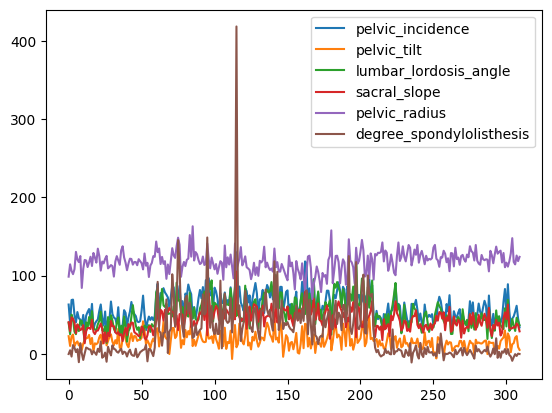

In [15]:
df.plot()
plt.show()

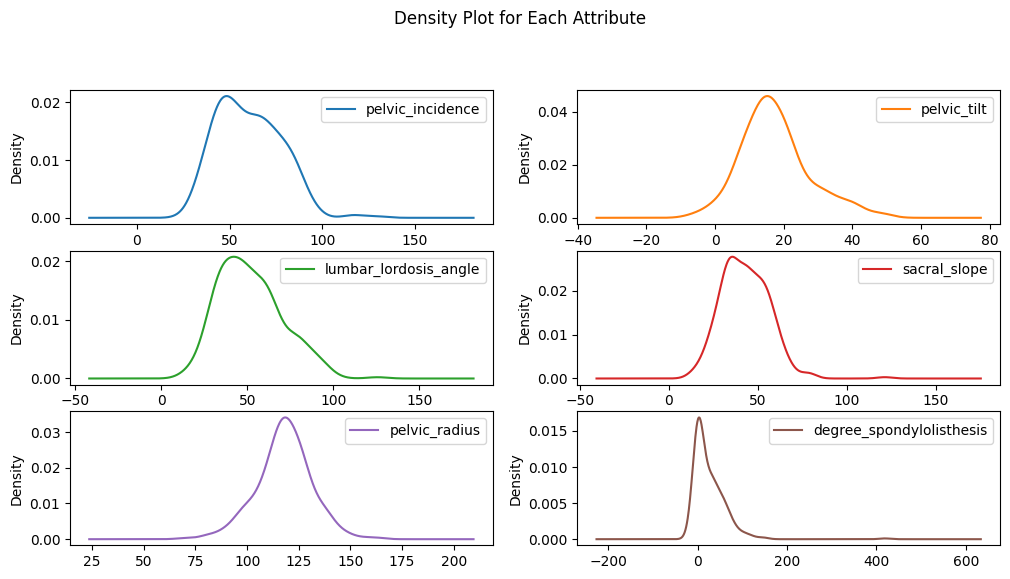

In [24]:
df.plot(kind='density',subplots=True, layout=(4,2), sharex=False, figsize=(12,8), title='Density Plot for Each Attribute')
plt.show()

Spondylolisthesis degree has outliers. Let's investigate that.

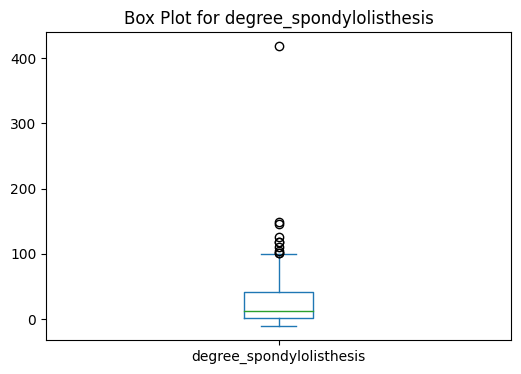

In [28]:
df['degree_spondylolisthesis'].plot(kind='box', figsize=(6,4), title='Box Plot for degree_spondylolisthesis')
plt.show()

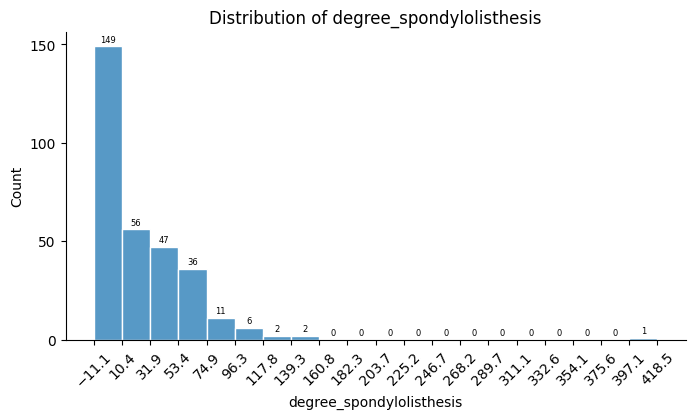

In [53]:
plt.figure(figsize=(8,4))

sns.histplot(data=df, x='degree_spondylolisthesis', kde=False, palette='Set1', bins=20, edgecolor='white')

plt.xticks(np.arange(df['degree_spondylolisthesis'].min(), 
                     df['degree_spondylolisthesis'].max()+1, 
                     21.48),
           rotation=45)

sns.despine()

plt.title('Distribution of degree_spondylolisthesis')

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.0f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=6, color='black', xytext=(0, 5), textcoords='offset points')

plt.yticks(np.arange(0, 151, 50))

plt.show()

##### <b>4.2. Target variable analysis

In [54]:
df['class'].value_counts()

class
b'Abnormal'    210
b'Normal'      100
Name: count, dtype: int64

The data are quite unbalanced

In [55]:
class_mapper = {b'Abnormal':1,b'Normal':0}
df['class']=df['class'].replace(class_mapper)

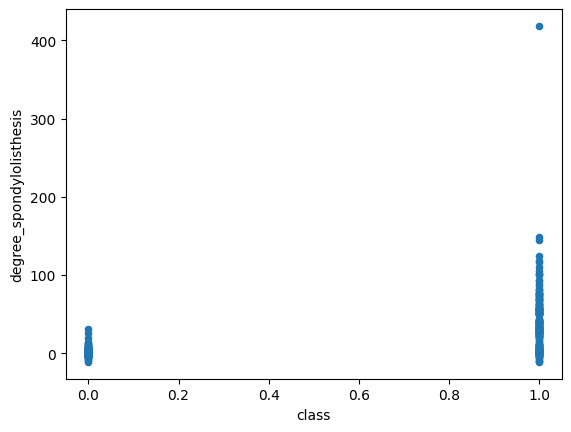

In [57]:
df.plot.scatter(y='degree_spondylolisthesis',x='class')
plt.show()

##### <b>4.3. Multivariate Analysis 

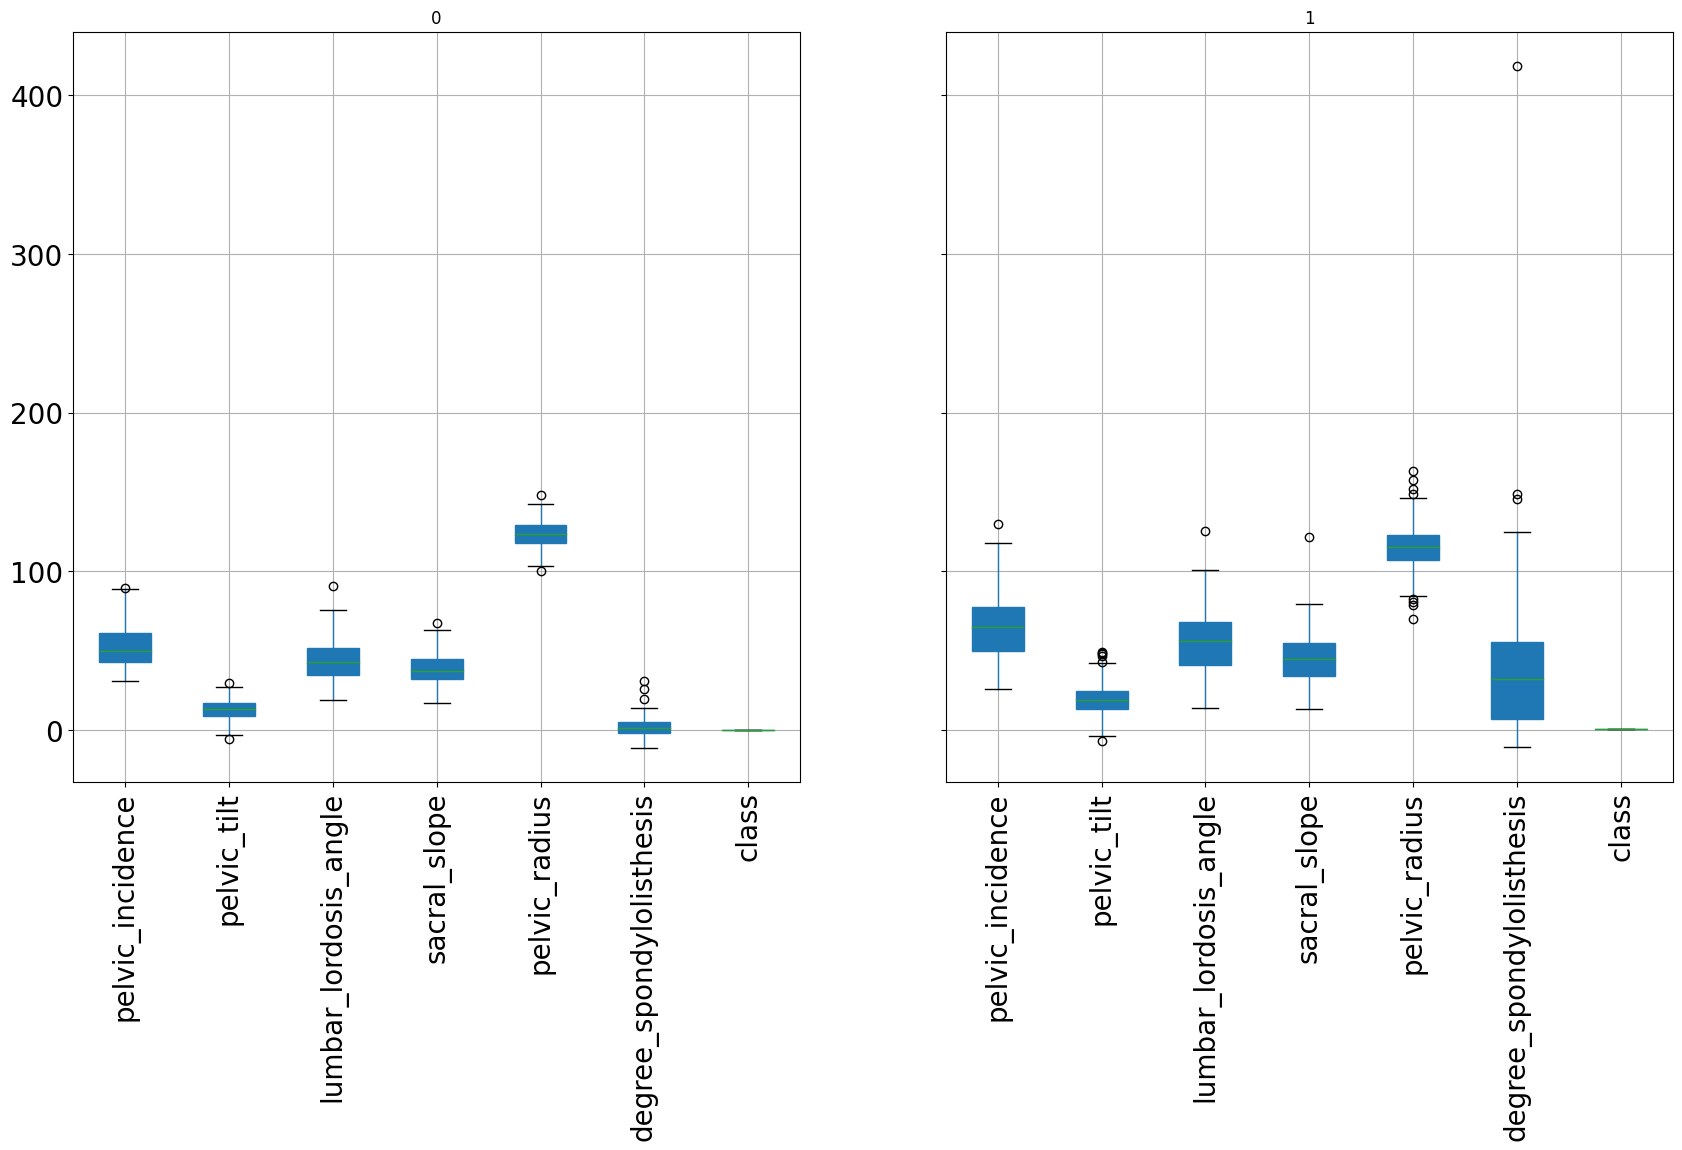

In [60]:
df.groupby('class').boxplot(fontsize=20,rot=90,figsize=(20,10),patch_artist=True)
plt.show()

In [61]:
corr_matrix = df.corr()
corr_matrix["class"].sort_values(ascending=False)

class                       1.000000
degree_spondylolisthesis    0.443687
pelvic_incidence            0.353336
pelvic_tilt                 0.326063
lumbar_lordosis_angle       0.312484
sacral_slope                0.210602
pelvic_radius              -0.309857
Name: class, dtype: float64

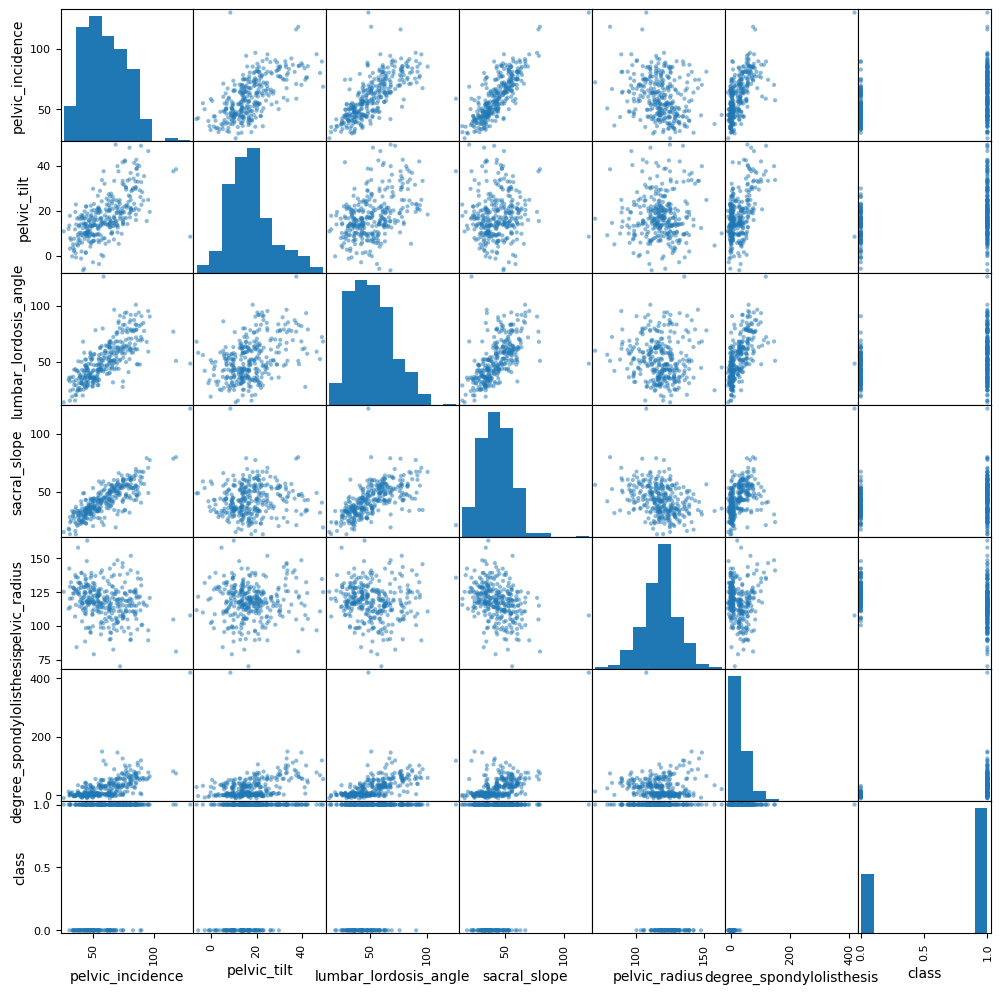

In [62]:
pd.plotting.scatter_matrix(df,figsize=(12,12))
plt.show()

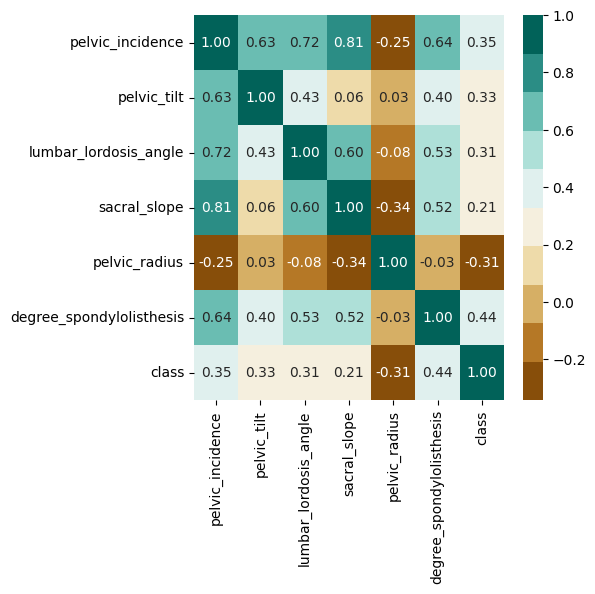

In [65]:
fig, ax = plt.subplots(figsize=(5, 5))
colormap = sns.color_palette("BrBG", 10)
sns.heatmap(corr_matrix, cmap=colormap, annot=True, fmt=".2f")
plt.show()

There is a strong correlation between pelvic_incidence and sacral_slope